# Wave Equation Dynamics from Spectral Polynomials

This notebook studies the one-dimensional wave equation

$$\partial_t^2 u = c^2\partial_x^2 u$$

with Dirichlet boundary conditions and zero initial velocity. For the positive discrete negative Laplacian `L`, the solution is

$$u(t)=\cos(c t \sqrt{L})u(0).$$

The square root and cosine make this a useful contrast with heat flow: the spectral transform is oscillatory rather than damping.

## Problem, QSVT Strategy, and Quantum Relevance

**System/problem.** This notebook studies a fixed-end one-dimensional wave equation.

**QSVT implementation.** It approximates the cosine propagator as a polynomial of the rescaled Laplacian. The matrices are deliberately small so the spectral rescaling, polynomial target, and validation quantities are visible in one executable notebook.

**Classical reference and quantum relevance.** Exact spectral wave evolution provides the reference displacement. Wave propagation is a matrix-function problem where QSVT is relevant for large sparse operators with efficient block encodings.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qsvt.pde import dirichlet_laplacian_1d
from qsvt.polynomials import eval_polynomial
from qsvt.spectral import (
    apply_function_to_hermitian,
    apply_polynomial_to_hermitian,
    eigh_hermitian,
)

np.set_printoptions(precision=4, suppress=True)

In [2]:
n_points = 16
wave_speed = 0.7
time = 0.18

x, L = dirichlet_laplacian_1d(n_points)
eigenvalues, _ = eigh_hermitian(L)
lambda_max = eigenvalues[-1]

A = 2.0 * L / lambda_max - np.eye(n_points)
beta = wave_speed * time * np.sqrt(lambda_max)

u0 = np.sin(np.pi * x) + 0.25 * np.sin(3.0 * np.pi * x)
np.linalg.eigvalsh(A)[[0, -1]], beta

(array([-0.9828,  1.    ]), np.float64(4.265725211247927))

## Vibrating string schematic

The spectral transform approximates the cosine wave propagator on a fixed-end string.


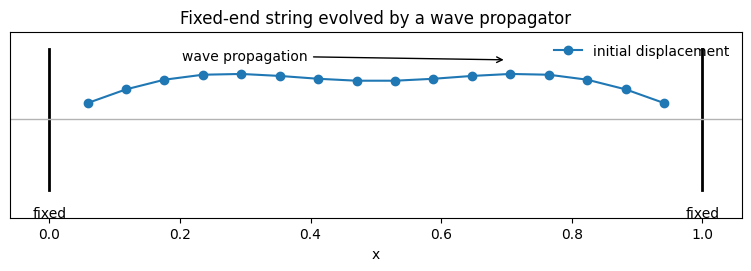

In [3]:
fig, ax = plt.subplots(figsize=(7.4, 2.6), constrained_layout=True)

ax.plot(
    x,
    0.32 * u0 / np.max(np.abs(u0)),
    "o-",
    color="tab:blue",
    label="initial displacement",
)
for boundary in [0.0, 1.0]:
    ax.plot([boundary, boundary], [-0.5, 0.5], color="black", linewidth=2.0)
    ax.text(boundary, -0.62, "fixed", ha="center", va="top")
ax.axhline(0.0, color="0.7", linewidth=1.0)
ax.annotate(
    "wave propagation",
    xy=(0.70, 0.42),
    xytext=(0.30, 0.42),
    arrowprops={"arrowstyle": "->"},
    ha="center",
)
ax.set_xlabel("x")
ax.set_title("Fixed-end string evolved by a wave propagator")
ax.set_xlim(-0.06, 1.06)
ax.set_ylim(-0.70, 0.62)
ax.set_yticks([])
ax.legend(frameon=False, loc="upper right")
plt.show()

## Approximate the wave propagator

On the rescaled variable `x in [-1, 1]`, the target polynomial is

$$p(x) \approx \cos\left(\beta\sqrt{\frac{x+1}{2}}\right).$$

In [4]:
degree = 18
fit_x = np.linspace(-1.0, 1.0, 1201)
fit_target = np.cos(beta * np.sqrt((fit_x + 1.0) / 2.0))
coeffs = np.polynomial.polynomial.polyfit(fit_x, fit_target, degree)

u_poly = apply_polynomial_to_hermitian(A, coeffs) @ u0
u_exact = (
    apply_function_to_hermitian(
        L,
        lambda lam: np.cos(wave_speed * time * np.sqrt(lam)),
    )
    @ u0
)

relative_error = np.linalg.norm(u_poly - u_exact) / np.linalg.norm(u_exact)
relative_error

np.float64(2.942102758155022e-15)

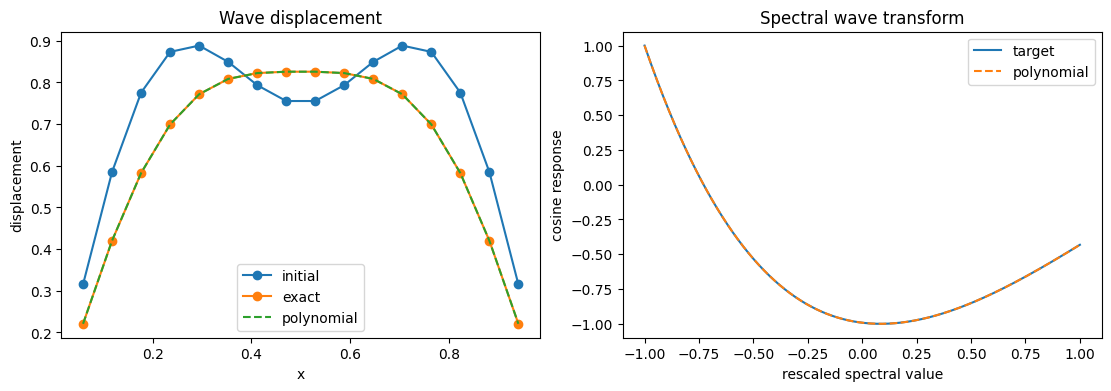

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)

axes[0].plot(x, u0, "o-", label="initial")
axes[0].plot(x, u_exact, "o-", label="exact")
axes[0].plot(x, u_poly, "--", label="polynomial")
axes[0].set_xlabel("x")
axes[0].set_ylabel("displacement")
axes[0].set_title("Wave displacement")
axes[0].legend()

plot_x = np.linspace(-1.0, 1.0, 500)
axes[1].plot(plot_x, np.cos(beta * np.sqrt((plot_x + 1.0) / 2.0)), label="target")
axes[1].plot(plot_x, eval_polynomial(coeffs, plot_x), "--", label="polynomial")
axes[1].set_xlabel("rescaled spectral value")
axes[1].set_ylabel("cosine response")
axes[1].set_title("Spectral wave transform")
axes[1].legend()

plt.show()

## Validation

Compact checks for the expected numerical behavior.

In [6]:
assert np.isfinite(relative_error)
assert relative_error < 1e-10
assert u_poly.shape == u_exact.shape == u0.shape

print(f"beta: {beta:.3f}")
print(f"relative_error: {relative_error:.3e}")
print("validation: passed")

beta: 4.266
relative_error: 2.942e-15
validation: passed
